# Uniaxial Concrete

{download}`Download <material-0003.ipynb>`

In [1]:
from numpy import sin, linspace, pi
import numpy as np
from utilities import mark_slope
import matplotlib.pyplot as plt


In [2]:
from xara.units.english import ksi, psi
from math import sqrt

# nominal concrete compressive strength
fc = -8.5*ksi              # Concrete compressive strength ksi   (+Tension -Compression)
Ec = 57*ksi*sqrt(-fc/psi)  # Concrete Elastic Modulus

# unconfined concrete
ec0 = -0.003             # strain at maximum strength of unconfined concrete
fc2U = 0.2*fc            # ultimate stress
ecu = -0.01              # strain at ultimate stress
_lambda = 0.1              # ratio between unloading slope at ecu and initial slope Ec

# tensile-strength properties
ftU = -0.14*fc           # tensile strength +tension
Ets = ftU/0.002            # tension softening stiffness

In [3]:
import xara 
# (Todeschini parabola) 
concrete01 = xara.UniaxialMaterial("Concrete01", 
    Fc=fc, 
    nu=0.2, 
    ec0=ec0, 
    Fcu=fc2U, 
    ecu=ecu, 
)


strain = -0.005*sin(linspace(0, 2.0*pi, 100))

stress = []
with concrete01 as tmp:

    for e in strain:
        stress.append(tmp.getStress(e, commit=True)/fc)


Now that the stress and strain are stored, the can be plotted using `matplotlib`

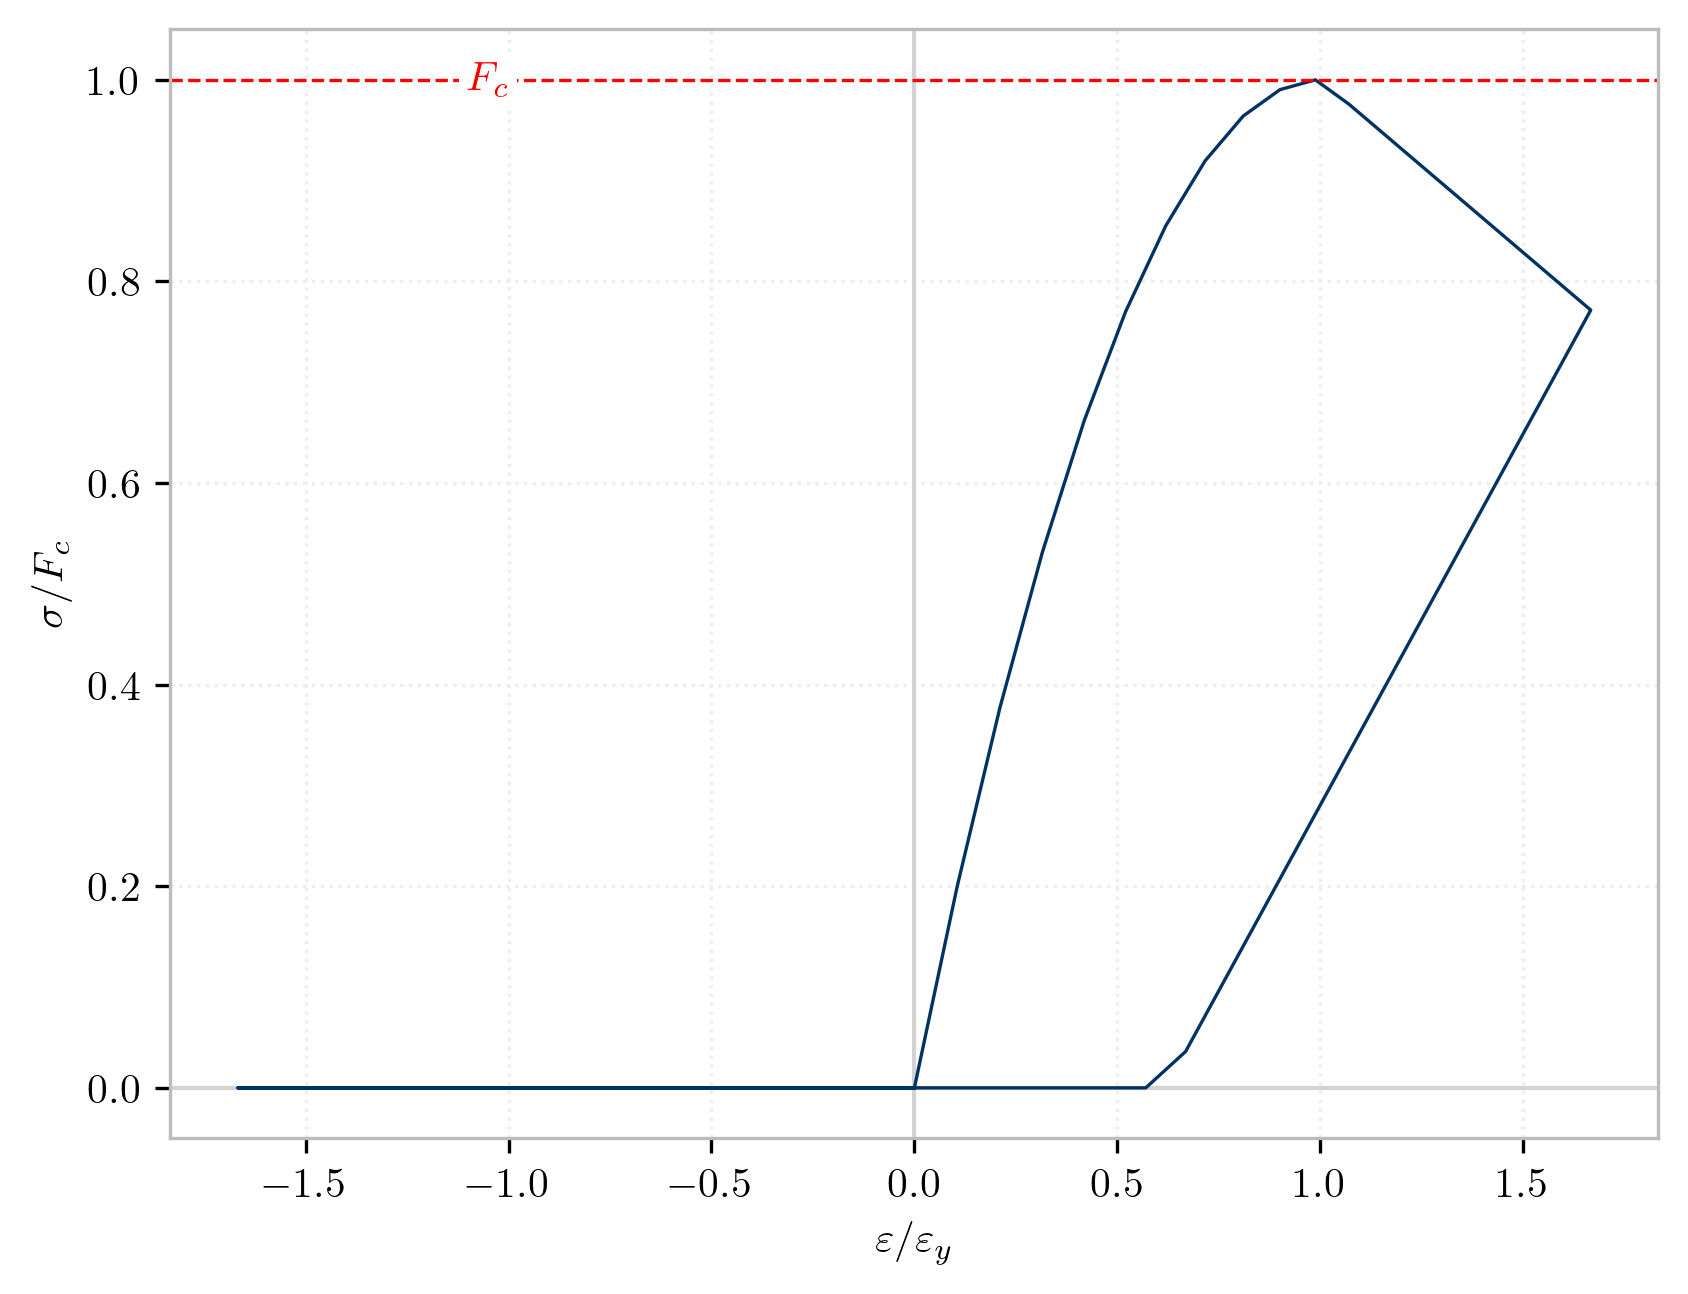

In [4]:

# create a plotting figure
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)
ln = ax.plot(strain/ec0, stress)

# mark_slope(ax, ln[0], 0.25, 0.75, iend=20, label="$E$", color='k', ls='--')
ax.axhline(y=1, color='r', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='r', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/F_c$");

In [5]:
ConcreteMaterials = [
    xara.UniaxialMaterial(
        type="Concrete01",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,#-1,#
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete02",
        nu=0.2,
        Fc=fc,
        ec0=ec0,
        Fcu=fc2U,
        ecu=ecu,
        ft=ftU,
        Ets=Ets,
        # Ec = Ec,
    ),
    xara.UniaxialMaterial(
        type="Concrete04",
        Fc=fc,
        nu=0.2,
        ec0=ec0,
        # Fcu=fc2U,
        ecu=ecu,#-1,#
        Ec = Ec,
    )
]

## Compression Envelope

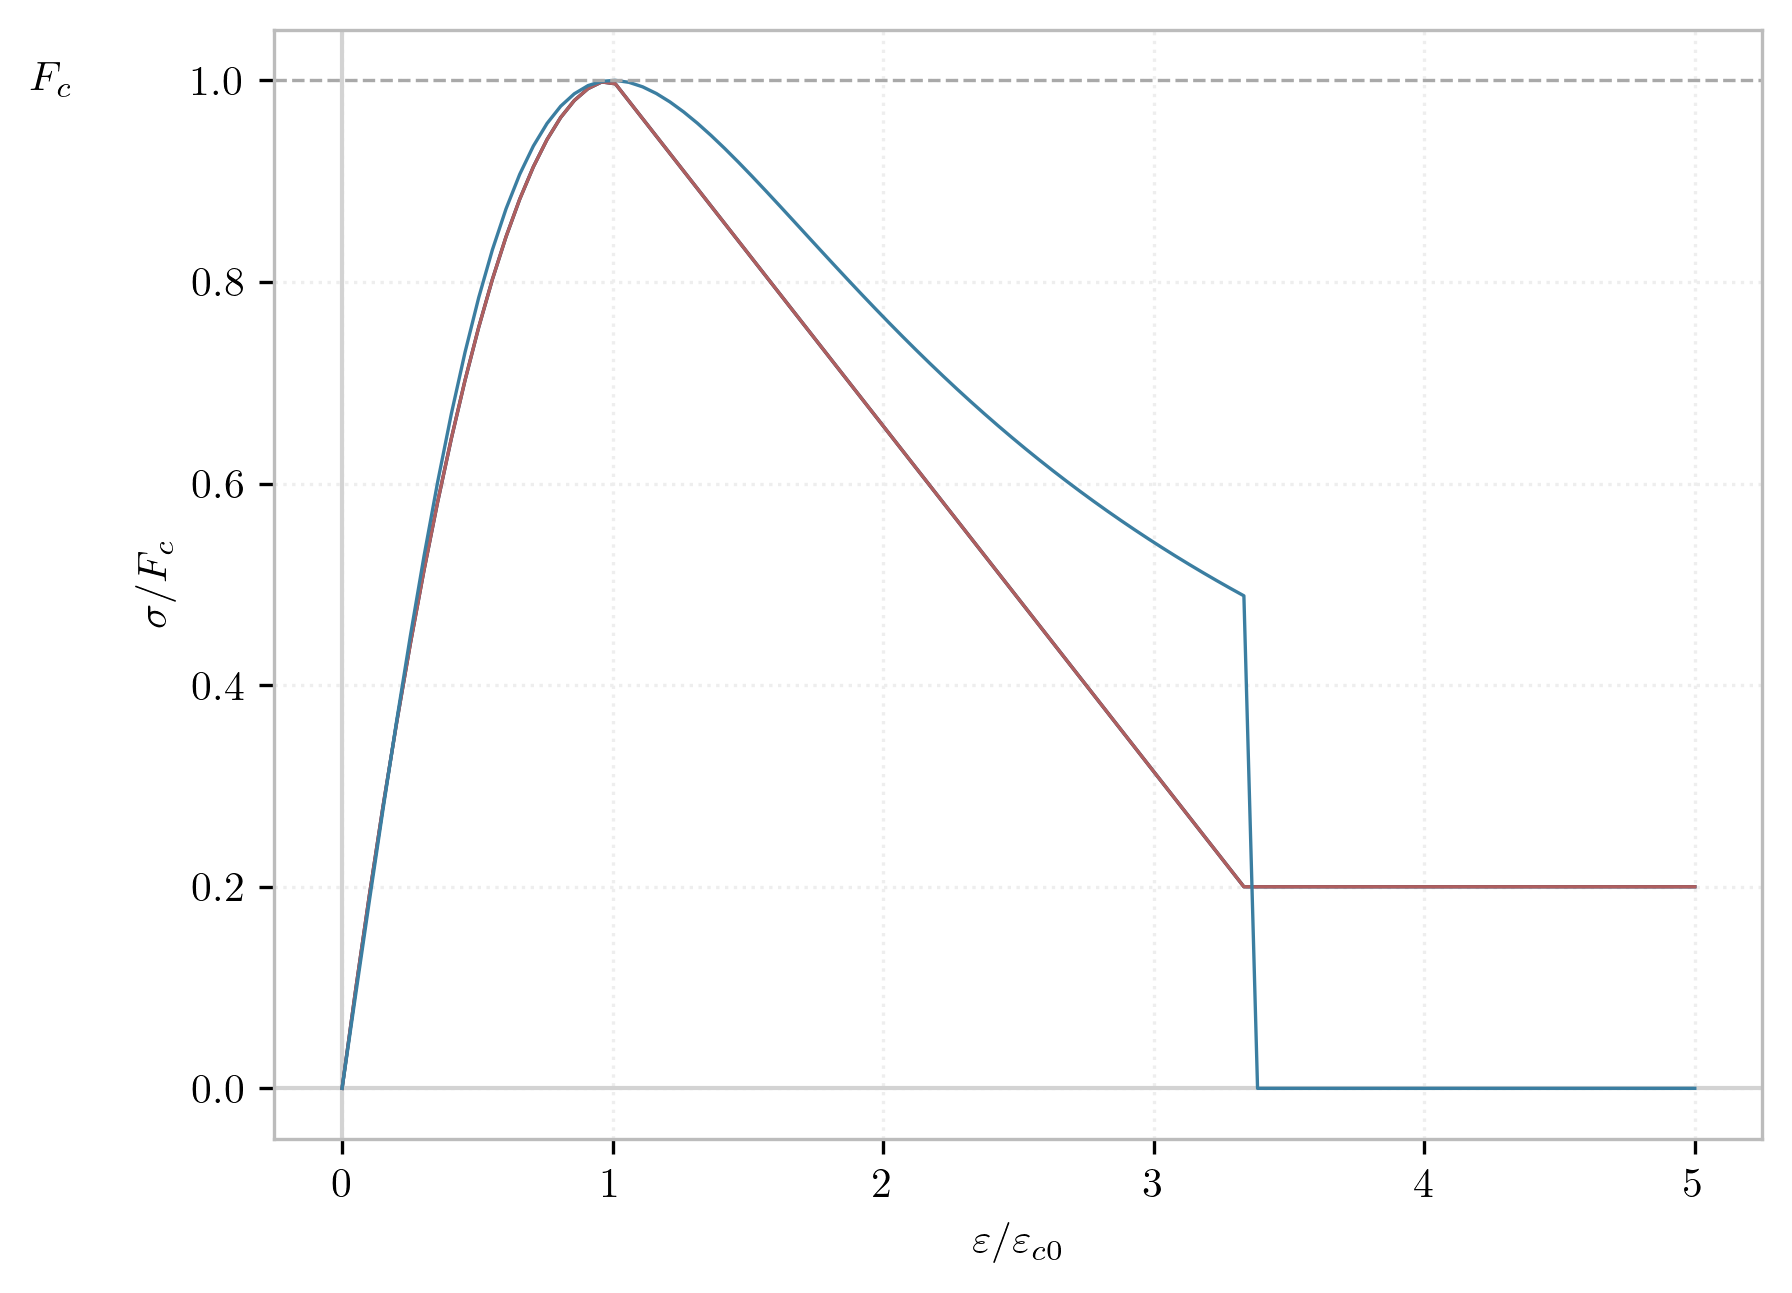

In [6]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, 5*ec0, 100)


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain])


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");
# ax.legend();

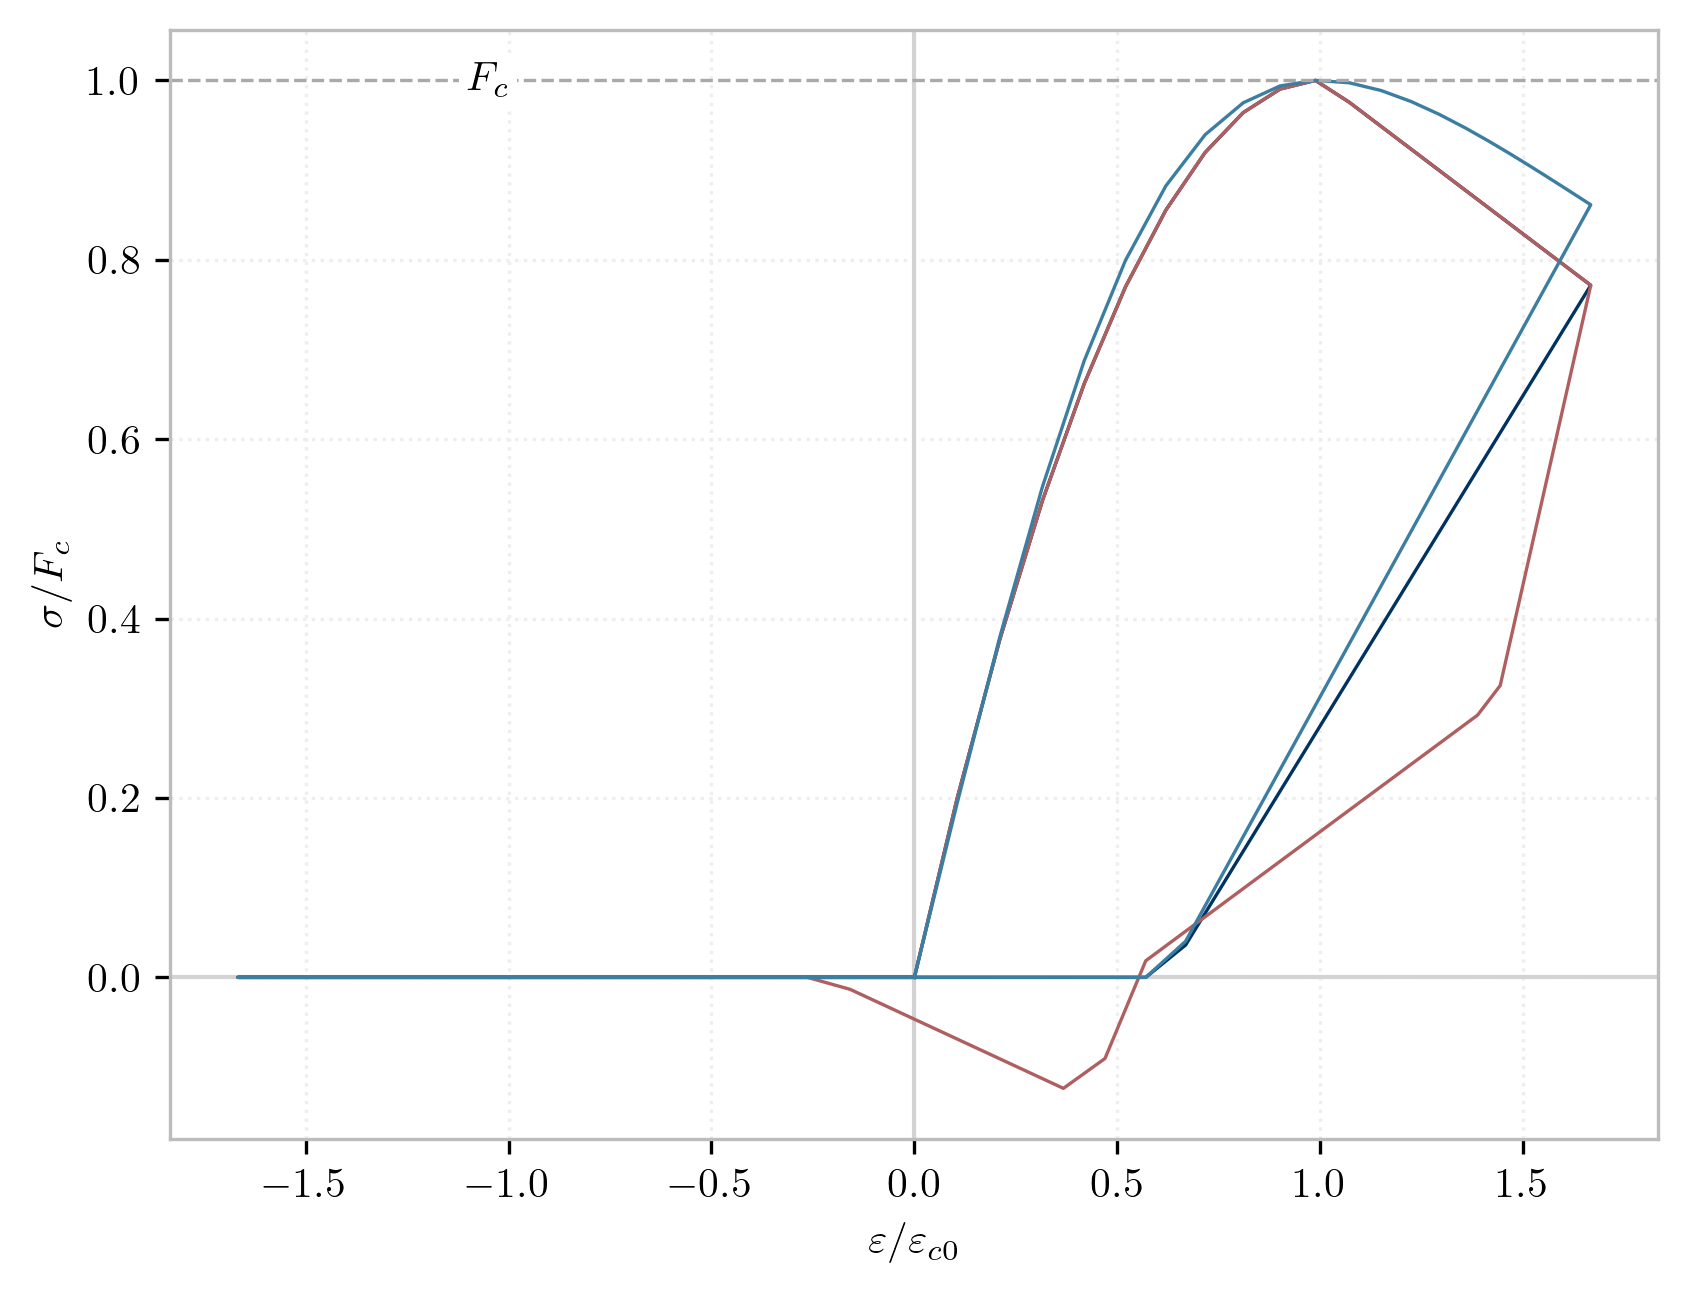

In [7]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = -0.005*sin(linspace(0, 2.0*pi, 100))


for material in ConcreteMaterials:
    with material as tmp:
        ln = ax.plot(strain/ec0, 
                    [tmp.getStress(e, commit=True)/fc for e in strain])

# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$F_c$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_{c0}$")
ax.set_ylabel(r"$\sigma/F_c$");

In [8]:

# strain = 0.01*(sin(linspace(0, 3.5*pi, 300))**2-0.01)*linspace(0.5, 1, 300)**2


# fig, ax = plt.subplots()
# with uniaxial.Steel02(Fy, Es, 0.02, 15, 0.925, 0.15, 0.05, 1, 0, 1).handle() as mat:
#     ln = ax.plot(strain/(Fy/Es), 
#                  [mat.getStress(e, commit=True)/Fy for e in strain],
#                  )


# # Draw a horizontal line at the yield stress Fy
# ax.axhline(y=1, color='darkgrey', linestyle='--')
# ax.text(-1, 1, r"$\sigma_y$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

# ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
# ax.set_ylabel(r"$\sigma/\sigma_y$")
# ax.legend()